## Imports

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# NLP tools
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("adityasureshgithub/digital-extremism-detection-curated-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'digital-extremism-detection-curated-dataset' dataset.
Path to dataset files: /kaggle/input/digital-extremism-detection-curated-dataset


In [3]:
print(os.listdir(path))

['extremism_data_final.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'extremism_data_final.csv'))

## Explore The Data

In [5]:
df.head()

,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST
3,halal factories should burn to the ground,EXTREMIST
4,nhs should burn to the ground,EXTREMIST


In [6]:
df.shape

(3895, 2)

In [7]:
df.isna().sum().sum()

np.int64(1)

In [8]:
df.duplicated().sum().sum()

np.int64(911)

In [9]:
df.shape

(3895, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3895 entries, 0 to 3894
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Original_Message  3894 non-null   object
 1   Extremism_Label   3895 non-null   object
dtypes: object(2)
memory usage: 61.0+ KB


## Visualize The Data

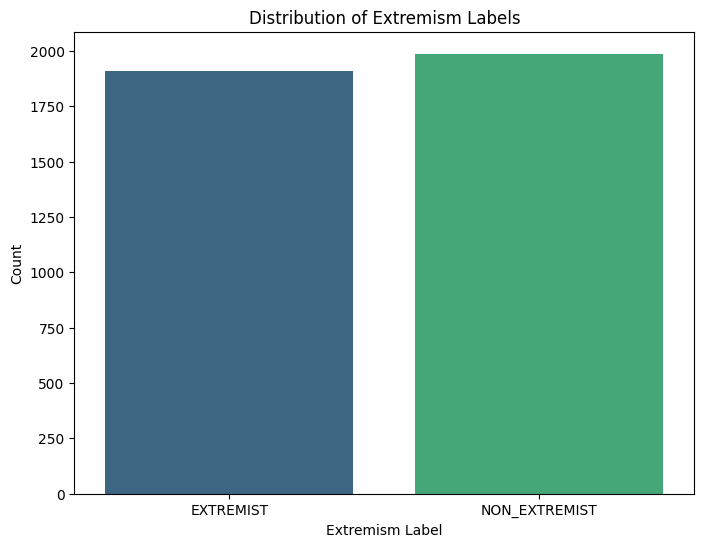

In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Extremism_Label', palette='viridis')
plt.title('Distribution of Extremism Labels')
plt.xlabel('Extremism Label')
plt.ylabel('Count')
plt.show()

## Preprocessing


In [12]:
# Drop missing rows
df = df.dropna(subset=['Original_Message'])

In [13]:
dup_count = df['Original_Message'].duplicated().sum()
dup_count


np.int64(1119)

In [14]:
dups = df[df['Original_Message'].duplicated(keep=False)]
dups.sort_values("Original_Message").head(20)


,Original_Message,Extremism_Label
1446,a boy does everything to finish school with fl...,EXTREMIST
1296,a boy does everything to finish school with fl...,EXTREMIST
92,a boy does everything to finish school with fl...,EXTREMIST
2230,a bubonic plague is from china as for having o...,EXTREMIST
894,a bubonic plague is from china as for having o...,EXTREMIST
892,a cunt this is a pathetic attempt as a master ...,EXTREMIST
2228,a cunt this is a pathetic attempt as a master ...,EXTREMIST
1047,a simile to baggage nice game bark is baggage ...,EXTREMIST
2383,a simile to baggage nice game bark is baggage ...,EXTREMIST
1017,a smuggler explains how he helped fighters alo...,NON_EXTREMIST


In [15]:
conflicts = df.groupby("Original_Message")['Extremism_Label'].nunique()
conflicts = conflicts[conflicts > 1]  # different labels
conflicts


,Extremism_Label
Original_Message,
abvp what a slut floated to bypass the ban on rss rss what a slut banned for spreading hate and bigotry through violence and terrorism part of abp dna to go around beating up people curtailing discussion etc abvpkagundaraj du sendthemhome,2
africa for africans asia for asians white countries for everyone is white genocide some basic truths access to white people are not a human right easy come easy go,2
africa for africans asia for asians white countries for everyone is white genocide to ignore the role of the immigration invasion and white genocide in the housing disaster is not just irresponsible its criminal,2
again the only thing that so called refugees bring to the righteous western world is terrorism and sexual criminality the true german people know this now they are telling the fake news politicians too other germany ref,2
ahshshsjs i am going to kill a bitch my girl got what she deserves because she got talent assad how can people discredit her like that,2
...,...
wow polish mp shocks british media our country is safe because whatever didnt accept illegal muslim migrants this is the reason why whatever had not even one terrorist attack we can be called populists,2
you are the lowest kind of skank to attack a gold star widow based on your tweets i,2
you dam stupid asshole they do not kill animals it for women with breast cancer you dam bitch,2


In [16]:
conflicted_msgs = conflicts.index.tolist()

df[df['Original_Message'].isin(conflicted_msgs)].sort_values("Original_Message").head(50)


,Original_Message,Extremism_Label
1420,abvp what a slut floated to bypass the ban on ...,NON_EXTREMIST
1270,abvp what a slut floated to bypass the ban on ...,EXTREMIST
66,abvp what a slut floated to bypass the ban on ...,EXTREMIST
170,africa for africans asia for asians white coun...,EXTREMIST
1524,africa for africans asia for asians white coun...,NON_EXTREMIST
136,africa for africans asia for asians white coun...,EXTREMIST
1490,africa for africans asia for asians white coun...,NON_EXTREMIST
1292,again the only thing that so called refugees b...,EXTREMIST
88,again the only thing that so called refugees b...,EXTREMIST
1442,again the only thing that so called refugees b...,NON_EXTREMIST


from the aabove info we can clearly drop the duplies

In [17]:
# Drop Duplies
df = df.drop_duplicates()

In [18]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
# Remove important words from stopwords
important_words = {"not", "no", "never", "should", "must"}
stop_words = stop_words - important_words

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # Remove URLs
    text = re.sub(r"&\w+;", "", text)  # HTML entities
    text = re.sub(r"[^\w\s!?]", " ", text)  # Keep ! ? because aggression
    text = re.sub(r"\d+", "", text)  # Remove digits
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize + Lemma
    words = [lemmatizer.lemmatize(w)
             for w in text.split()
             if w not in stop_words]

    return " ".join(words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
# Apply Cleaning
df['clean_text'] = df['Original_Message'].apply(clean_text)
df[['Original_Message','clean_text']].head(10)


,Original_Message,clean_text
0,sixth forms should burn to the ground,sixth form should burn ground
1,whatever should burn benders to the ground,whatever should burn bender ground
2,factories should burn to the ground,factory should burn ground
3,halal factories should burn to the ground,halal factory should burn ground
4,nhs should burn to the ground,nh should burn ground
5,nhs should burn to the ground because it is fu...,nh should burn ground full foreigner
6,around the world you will find a number of peo...,around world find number people stab others bl...
7,around the world you will find a number of peo...,around world find number people woman should k...
8,around the world you will find a number of peo...,around world find number people traveler want ...
9,the malala fund is trash let us shoot the stup...,malala fund trash let u shoot stupid muslim


In [20]:
df.shape

(2983, 3)

In [21]:
df["Extremism_Label"].unique()

array(['EXTREMIST', 'NON_EXTREMIST'], dtype=object)

In [22]:
# Encode The Labels
df['label'] = df['Extremism_Label'].map({
    'NON_EXTREMIST': 0,
    'EXTREMIST': 1
})

df[['Extremism_Label', 'label']].head()


,Extremism_Label,label
0,EXTREMIST,1
1,EXTREMIST,1
2,EXTREMIST,1
3,EXTREMIST,1
4,EXTREMIST,1


In [23]:
df['label'].value_counts()


,count
label,
0,1578
1,1405


## Train-Test Split

In [24]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((2386,), (597,), (2386,), (597,))

## TF-IDF Vectorization

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2              # ignore ultra-rare tokens
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((2386, 6353), (597, 6353))

## Initialize Logistic Regression model

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    solver='liblinear'   # good for small/medium sparse TF-IDF
)

# Train
log_reg.fit(X_train_tfidf, y_train)

# Predict
y_pred = log_reg.predict(X_test_tfidf)
y_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Logistic Regression Accuracy : {acc:.4f}")
print(f"Logistic Regression ROC-AUC  : {roc:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['NON_EXTREMIST', 'EXTREMIST']))


Logistic Regression Accuracy : 0.7471
Logistic Regression ROC-AUC  : 0.8492

Classification Report:

               precision    recall  f1-score   support

NON_EXTREMIST       0.78      0.73      0.75       316
    EXTREMIST       0.72      0.76      0.74       281

     accuracy                           0.75       597
    macro avg       0.75      0.75      0.75       597
 weighted avg       0.75      0.75      0.75       597



## Confusion Matrix of Logistic Regression model

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[232  84]
 [ 67 214]]


## Train Linear SVM (SVC)

In [28]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVM
svm_model = LinearSVC()

# Train
svm_model.fit(X_train_tfidf, y_train)

# Predict
svm_pred = svm_model.predict(X_test_tfidf)

# Metrics
svm_acc = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy : {svm_acc:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, svm_pred, target_names=['NON_EXTREMIST', 'EXTREMIST']))


SVM Accuracy : 0.7136

Classification Report:

               precision    recall  f1-score   support

NON_EXTREMIST       0.74      0.72      0.73       316
    EXTREMIST       0.69      0.71      0.70       281

     accuracy                           0.71       597
    macro avg       0.71      0.71      0.71       597
 weighted avg       0.71      0.71      0.71       597



## Confusion Matrix  of SVM

In [29]:
cm = confusion_matrix(y_test, svm_pred)
print(cm)



[[226  90]
 [ 81 200]]


## Stacked Model (LR + SVM) + Full Metrics

In [30]:
estimators = [
    ('lr', LogisticRegression(max_iter=1000, solver='liblinear')),
    ('svm', LinearSVC())
]

# -Define stacking classifier
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='auto',   # uses predict_proba / decision_function
    n_jobs=-1
)

# Train
stack_model.fit(X_train_tfidf, y_train)

# Predict
stack_pred = stack_model.predict(X_test_tfidf)
stack_proba = stack_model.predict_proba(X_test_tfidf)[:, 1]

# Metrics
stack_acc = accuracy_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_proba)

print(f"Stacked Model (LR + SVM) Accuracy : {stack_acc:.4f}")
print(f"Stacked Model (LR + SVM) ROC-AUC  : {stack_auc:.4f}\n")

print("Stacked Model Classification Report:\n")
print(classification_report(
    y_test, stack_pred,
    target_names=['NON_EXTREMIST', 'EXTREMIST']
))


Stacked Model (LR + SVM) Accuracy : 0.7571
Stacked Model (LR + SVM) ROC-AUC  : 0.8528

Stacked Model Classification Report:

               precision    recall  f1-score   support

NON_EXTREMIST       0.79      0.73      0.76       316
    EXTREMIST       0.72      0.78      0.75       281

     accuracy                           0.76       597
    macro avg       0.76      0.76      0.76       597
 weighted avg       0.76      0.76      0.76       597



## Confusion MatrixStacked Model (LR + SVM)

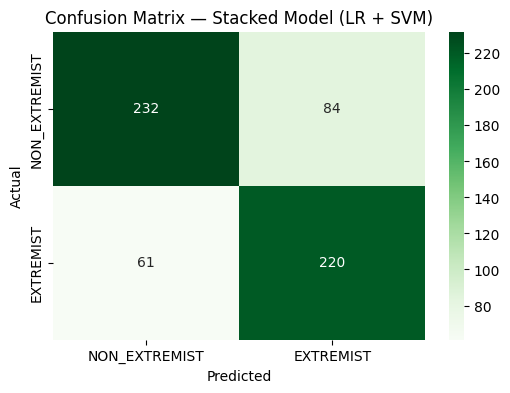

In [31]:
cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['NON_EXTREMIST','EXTREMIST'],
    yticklabels=['NON_EXTREMIST','EXTREMIST']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Stacked Model (LR + SVM)')
plt.show()